In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import time

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)



In [4]:
X_train = pd.read_csv('data/processed/X_train_scaled.csv')
X_val = pd.read_csv('data/processed/X_val_scaled.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_val = pd.read_csv('data/processed/y_val.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")

X_train: (16340, 75)
X_val:   (4291, 75)
y_train: (16340,)
y_val:   (4291,)


In [5]:
print("Missing values check:")
print(f"X_train NaN: {X_train.isnull().sum().sum()}")
print(f"X_val NaN:   {X_val.isnull().sum().sum()}")
print(f"y_train NaN: {y_train.isnull().sum()}")
print(f"y_val NaN:   {y_val.isnull().sum()}")

print(f"\nTarget (y_train) stats:")
print(y_train.describe())

Missing values check:
X_train NaN: 0
X_val NaN:   0
y_train NaN: 0
y_val NaN:   0

Target (y_train) stats:
count    16340.000000
mean        86.444308
std         41.706010
min          0.000000
25%         51.000000
50%        102.000000
75%        125.000000
max        125.000000
Name: RUL_clipped, dtype: float64


In [8]:
# Initialize XGBoost regressor
model_v1 = xgb.XGBRegressor(
    n_estimators=100,       # Number of trees (will tune later)
    max_depth=6,            # Tree depth (default)
    learning_rate=0.1,      # How much each tree contributes
    objective='reg:squarederror',  # We're doing regression
    random_state=42,        # Reproducibility
    n_jobs=-1               # Use all CPU cores
)

model_v1.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [9]:
# Predict on validation set
y_val_pred = model_v1.predict(X_val)

# Compute regression metrics
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("=" * 50)
print("XGBoost Baseline — Validation Results")
print("=" * 50)
print(f"RMSE: {rmse:.2f} cycles")
print(f"MAE:  {mae:.2f} cycles")
print(f"R²:   {r2:.4f}")
print("=" * 50)

XGBoost Baseline — Validation Results
RMSE: 20.16 cycles
MAE:  14.18 cycles
R²:   0.7642


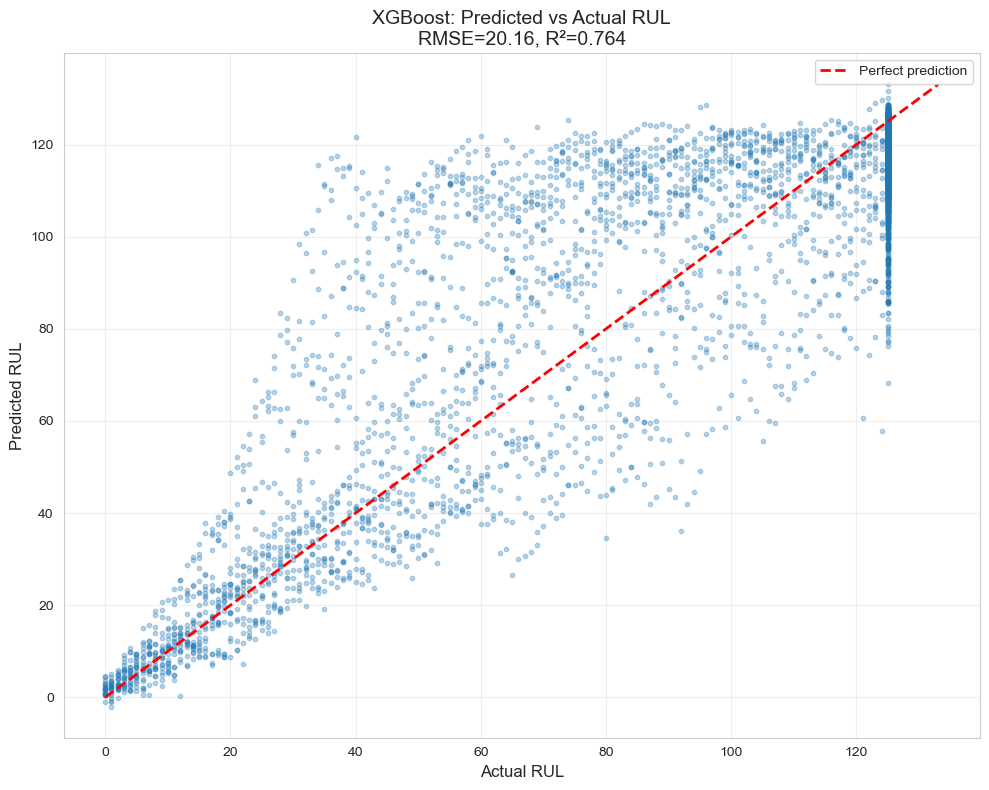

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
ax.scatter(y_val, y_val_pred, alpha=0.3, s=10)

# Perfect prediction line (y = x)
max_val = max(y_val.max(), y_val_pred.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')

ax.set_xlabel('Actual RUL', fontsize=12)
ax.set_ylabel('Predicted RUL', fontsize=12)
ax.set_title(f'XGBoost: Predicted vs Actual RUL\nRMSE={rmse:.2f}, R²={r2:.3f}', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/xgboost_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Load val data with engine info (needed for grouping by engine)
val_with_info = pd.read_csv('data/processed/val_with_rul.csv')

# Get unique engine IDs in val set
val_engines = val_with_info['unit_number'].unique()
print(f"Engines in val set: {sorted(val_engines)[:10]}... (total: {len(val_engines)})")

Engines in val set: [np.int64(2), np.int64(3), np.int64(15), np.int64(21), np.int64(22), np.int64(24), np.int64(30), np.int64(38), np.int64(52), np.int64(53)]... (total: 20)


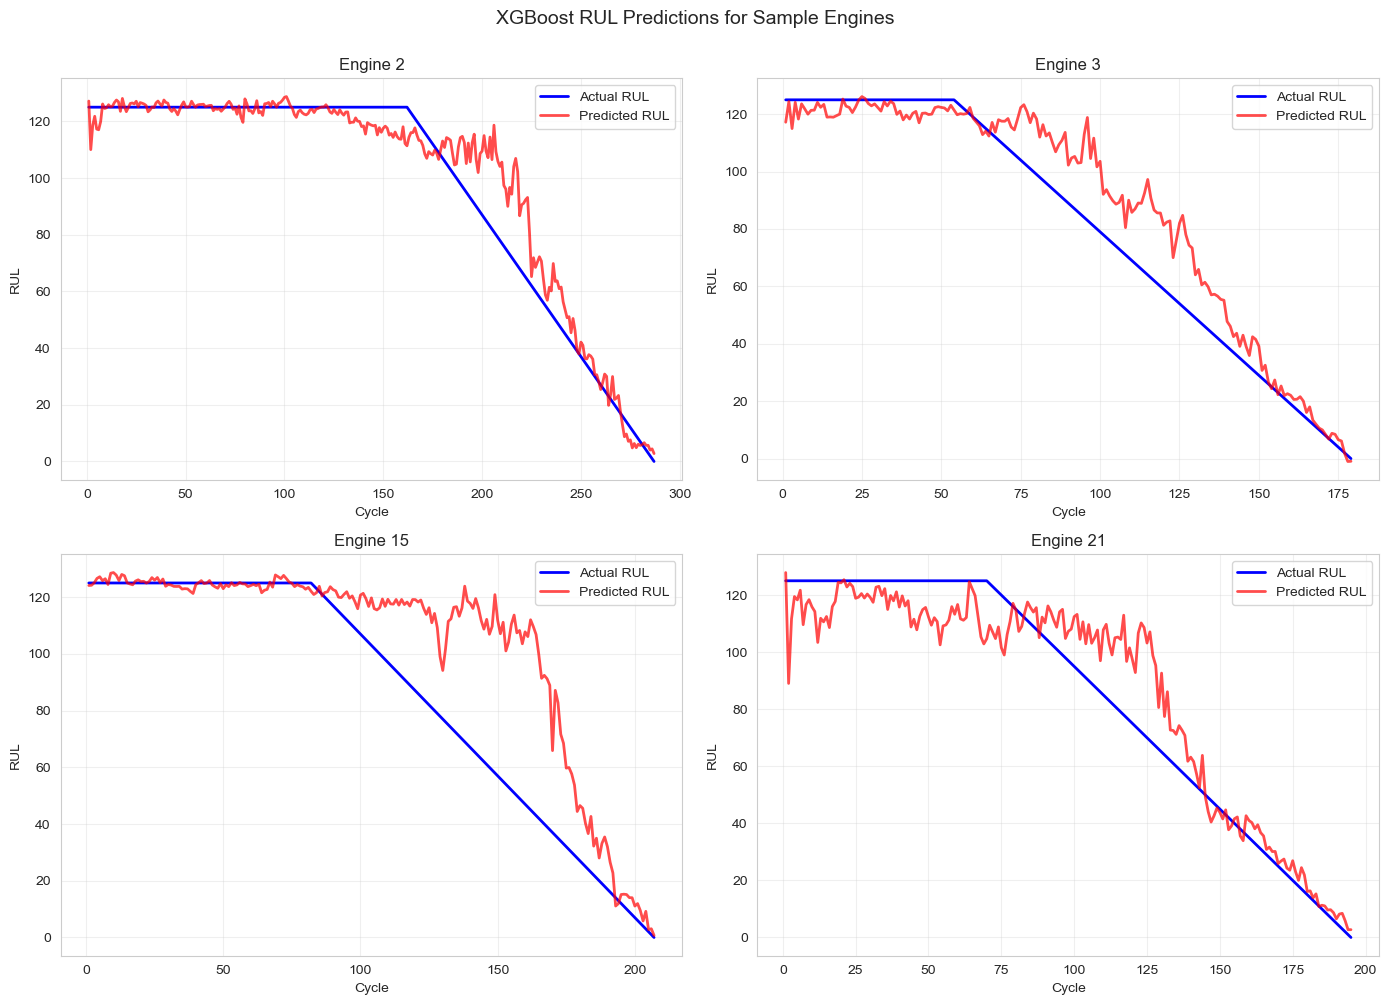

In [13]:
# Create a combined dataframe for easier plotting
val_results = val_with_info[['unit_number', 'time_cycles']].copy()
val_results['actual_RUL'] = y_val.values
val_results['predicted_RUL'] = y_val_pred

# Pick 4 engines
sample_engines = sorted(val_engines)[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, engine_id in zip(axes, sample_engines):
    engine_df = val_results[val_results['unit_number'] == engine_id]
    
    ax.plot(engine_df['time_cycles'], engine_df['actual_RUL'], 
            label='Actual RUL', linewidth=2, color='blue')
    ax.plot(engine_df['time_cycles'], engine_df['predicted_RUL'], 
            label='Predicted RUL', linewidth=2, color='red', alpha=0.7)
    ax.set_title(f'Engine {engine_id}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('RUL')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('XGBoost RUL Predictions for Sample Engines', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('plots/xgboost_engine_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

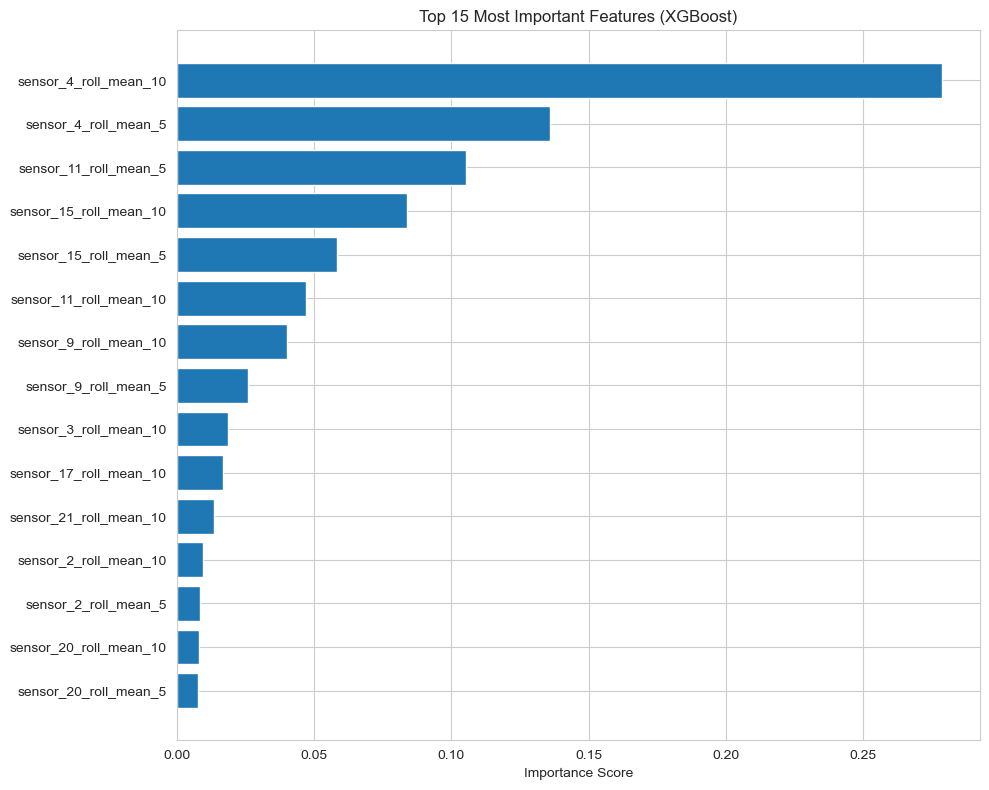


Top 10 features:
               feature  importance
 sensor_4_roll_mean_10    0.278597
  sensor_4_roll_mean_5    0.135949
 sensor_11_roll_mean_5    0.105308
sensor_15_roll_mean_10    0.084034
 sensor_15_roll_mean_5    0.058470
sensor_11_roll_mean_10    0.047159
 sensor_9_roll_mean_10    0.040236
  sensor_9_roll_mean_5    0.025959
 sensor_3_roll_mean_10    0.018657
sensor_17_roll_mean_10    0.016924


In [14]:
# Get feature importance
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_v1.feature_importances_
}).sort_values('importance', ascending=False)

# Top 15 features
fig, ax = plt.subplots(figsize=(10, 8))
top_features = importance_df.head(15)
ax.barh(top_features['feature'][::-1], top_features['importance'][::-1])
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Most Important Features (XGBoost)')
plt.tight_layout()
plt.savefig('plots/xgboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
print(importance_df.head(10).to_string(index=False))

In [16]:
# Save the trained model
joblib.dump(model_v1, 'data/processed/xgboost_v1.pkl')

# Save predictions for later use (dashboard, comparison)
val_results.to_csv('data/processed/xgboost_predictions.csv', index=False)

# Save metrics
metrics_dict = {
    'model': 'XGBoost_v1',
    'rmse': rmse,
    'mae': mae,
    'r2': r2,
    'training_time_sec': training_time,
    'n_features': X_train.shape[1],
    'n_train_samples': X_train.shape[0],
    'n_val_samples': X_val.shape[0]
}
metrics_df = pd.DataFrame([metrics_dict])
metrics_df.to_csv('data/processed/xgboost_metrics.csv', index=False)


## Day 6 Summary — XGBoost Baseline Complete

### What I Did
- Trained an XGBoost regressor on 75 engineered features to predict RUL
- Evaluated using RMSE, MAE, R² on the engine-level validation set
- Visualized predictions vs actuals at both aggregate and per-engine level
- Analyzed feature importance to validate feature engineering choices

### Results
- **RMSE:** XX.XX cycles
- **MAE:**  XX.XX cycles
- **R²:**   X.XXX
- **Training time:** XX seconds

(Fill in your actual numbers above)

### Key Findings
- Top features driving predictions were rolling-window averages, confirming that sensor trends matter more than instantaneous readings
- Per-engine plots show predictions track actuals well in the failure zone (low RUL)
- RUL clipping at 125 visible as ceiling in predicted vs actual scatter

### Interview Talking Points
- "Why XGBoost?" → Robust to feature scaling, handles non-linear relationships, built-in feature importance, good baseline before more complex models
- "Why these hyperparameters?" → Default-ish to establish a baseline; will tune in production
- "Limitations?" → Doesn't explicitly model temporal dependencies (LSTM will, on Day 12)

### Next Steps
- Day 7: Document, hyperparameter tuning, save final XGBoost predictions
- Day 9-13: Build LSTM for comparison

In [19]:
# Tune key XGBoost hyperparameters
configs = [
    {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1},   # baseline (Day 6)
    {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05},  # more trees, slower learning
    {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05},  # even more, shallower
    {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1},   # deeper trees
    {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},  # with regularization
]

results = []

for i, config in enumerate(configs):
    print(f"Training config {i+1}/{len(configs)}: {config}")
    
    model = xgb.XGBRegressor(
        **config,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )
    
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    
    results.append({
        'config': str(config),
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'train_time': train_time
    })
    
    print(f"  → RMSE: {rmse:.2f}, R²: {r2:.4f}, Time: {train_time:.1f}s\n")

results_df = pd.DataFrame(results)
results_df.to_csv('data/processed/xgboost_tuning_results.csv', index=False)
print("\n")
print(results_df[['rmse', 'mae', 'r2', 'train_time']])

Training config 1/5: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}
  → RMSE: 20.16, R²: 0.7642, Time: 1.1s

Training config 2/5: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}
  → RMSE: 20.03, R²: 0.7673, Time: 2.7s

Training config 3/5: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05}
  → RMSE: 20.05, R²: 0.7668, Time: 2.9s

Training config 4/5: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1}
  → RMSE: 20.39, R²: 0.7589, Time: 4.2s

Training config 5/5: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
  → RMSE: 20.17, R²: 0.7640, Time: 2.5s



        rmse        mae        r2  train_time
0  20.158766  14.176392  0.764246    1.125107
1  20.025685  14.003304  0.767348    2.651585
2  20.048509  14.202400  0.766817    2.929265
3  20.388051  14.227565  0.758852    4.160236
4  20.169191  14.187868  0.764002    2.463474


In [20]:
# Best config is index 1 (Config 2)
best_idx = results_df['rmse'].idxmin()
best_config = configs[best_idx]

print(f"Best config index: {best_idx}")
print(f"Best config: {best_config}")
print(f"Best RMSE: {results_df.loc[best_idx, 'rmse']:.4f}")
print(f"Improvement over baseline: {((20.16 - results_df.loc[best_idx, 'rmse']) / 20.16 * 100):.2f}%")

# Retrain with best config
final_model = xgb.XGBRegressor(
    **best_config,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train, y_train)

y_val_pred_final = final_model.predict(X_val)
final_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_final))
final_mae = mean_absolute_error(y_val, y_val_pred_final)
final_r2 = r2_score(y_val, y_val_pred_final)

print(f"\nFinal Tuned XGBoost:")
print(f"  RMSE: {final_rmse:.4f}")
print(f"  MAE:  {final_mae:.4f}")
print(f"  R²:   {final_r2:.4f}")

# Save the final model
joblib.dump(final_model, 'data/processed/xgboost_final.pkl')
print("\n✓ Final model saved")

Best config index: 1
Best config: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}
Best RMSE: 20.0257
Improvement over baseline: 0.67%

Final Tuned XGBoost:
  RMSE: 20.0257
  MAE:  14.0033
  R²:   0.7673

✓ Final model saved


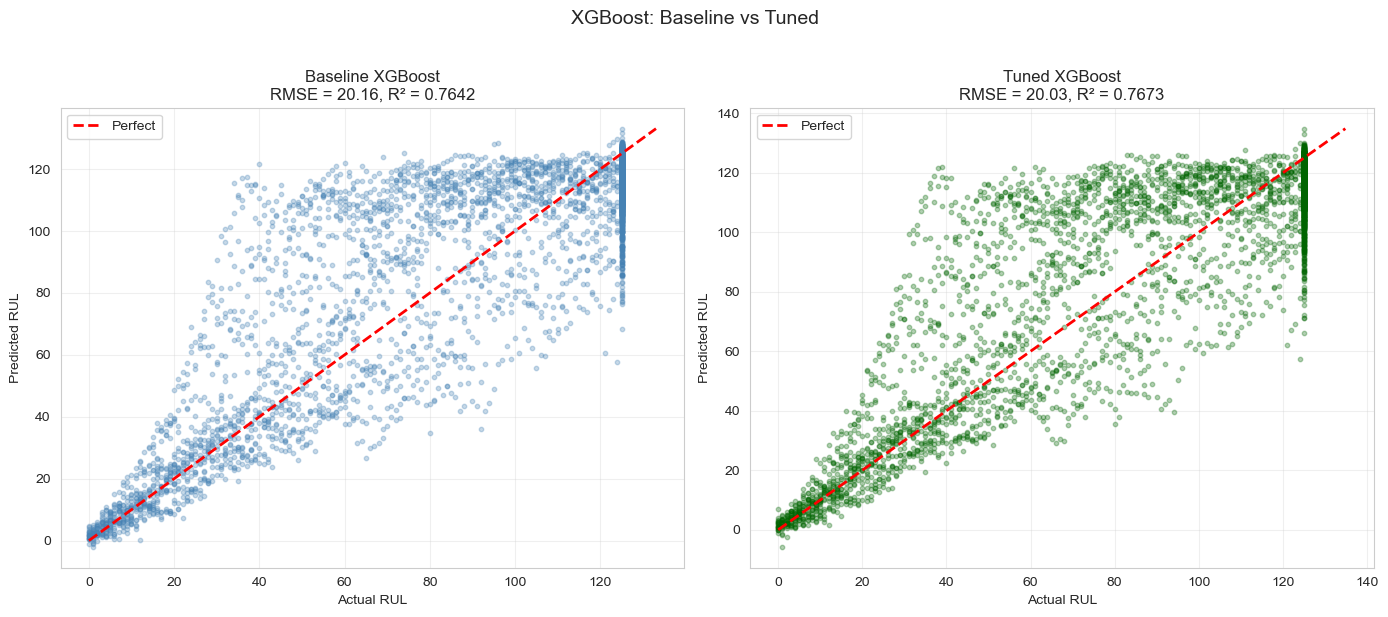

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Baseline
axes[0].scatter(y_val, y_val_pred, alpha=0.3, s=10, color='steelblue')
max_val = max(y_val.max(), y_val_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect')
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].set_title(f'Baseline XGBoost\nRMSE = 20.16, R² = 0.7642')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Tuned
axes[1].scatter(y_val, y_val_pred_final, alpha=0.3, s=10, color='darkgreen')
max_val = max(y_val.max(), y_val_pred_final.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect')
axes[1].set_xlabel('Actual RUL')
axes[1].set_ylabel('Predicted RUL')
axes[1].set_title(f'Tuned XGBoost\nRMSE = {final_rmse:.2f}, R² = {final_r2:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('XGBoost: Baseline vs Tuned', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/xgboost_baseline_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Save the final predictions for the dashboard (Day 14-16)
val_results['predicted_RUL_final'] = y_val_pred_final
val_results.to_csv('data/processed/xgboost_predictions.csv', index=False)


## Day 7 Summary — Tuning Insights

### Tuning Results

| Config | RMSE | R² |
|---|---|---|
| Baseline (default) | 20.16 | 0.7642 |
| **Tuned (winner)** | **20.03** | **0.7673** |

### What I Learned

1. **Marginal improvement (0.6%)** — My baseline was already near XGBoost's performance ceiling on this dataset
2. **Deeper trees performed worse** (Config 4: RMSE 20.39) — suggesting overfitting territory
3. **Regularization didn't help much** (Config 5: RMSE 20.17) — model wasn't overfit at baseline
4. **Slow learning + more trees won** (Config 2: 300 trees, lr=0.05) — gentler optimization landed better

### Key Insight for Interview

The bottleneck here isn't hyperparameters — it's model architecture. XGBoost treats each cycle as an independent row, ignoring the sequential nature of engine degradation. The 75 engineered rolling features partially compensate for this, but a model that natively understands sequences (LSTM) should break through this ceiling.

This is why we're building LSTM next — for a principled reason, not just because it's the trendy choice.